In [71]:
# ==============================
# Import Required Libraries
# ==============================

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Handle Imbalanced Data
from imblearn.over_sampling import SMOTE

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [72]:
df = pd.read_csv("creditcard.csv/creditcard.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

Dataset Loaded Successfully!
Shape: (284807, 31)


In [73]:
# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [74]:
print("Rows and Columns :", df.shape)

Rows and Columns : (284807, 31)


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [76]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [77]:
# Check Missing Values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [78]:
# Check Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1081


In [79]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (283726, 31)


In [80]:
# Class Distribution
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [81]:
(df['Class'].value_counts(normalize=True) * 100).round(4)

Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64

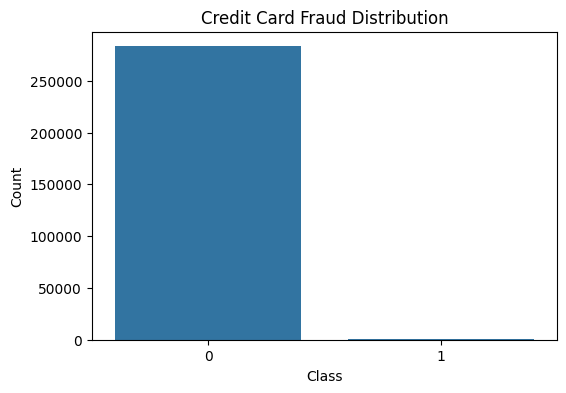

In [82]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Class")

plt.title("Credit Card Fraud Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

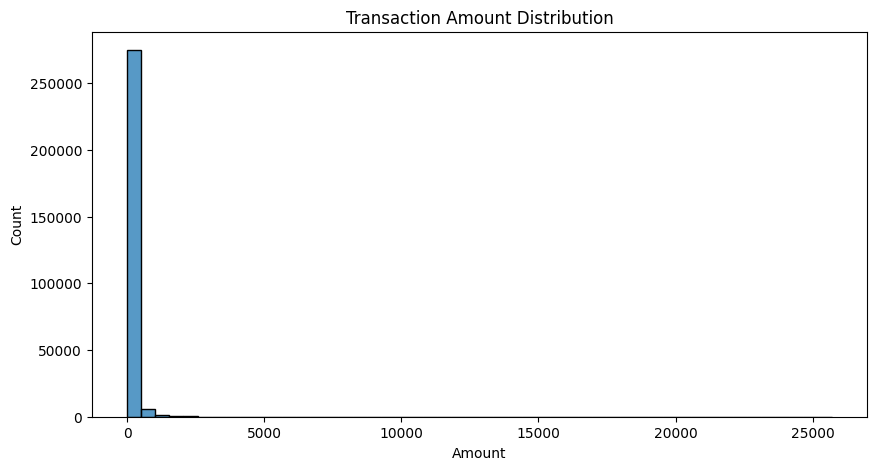

In [83]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"],bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

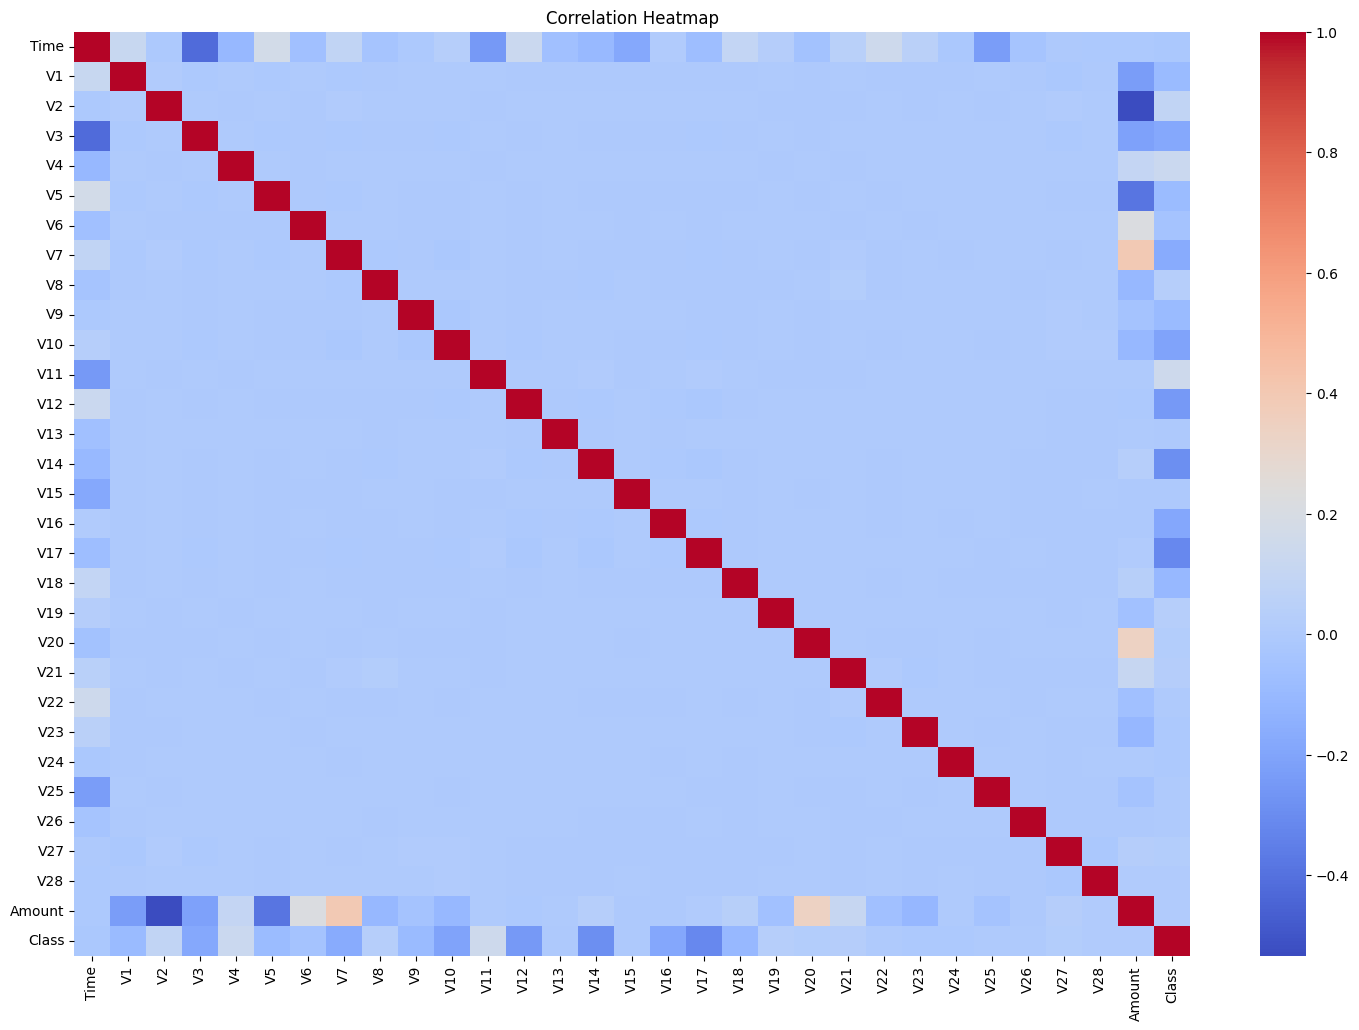

In [84]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(),cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [85]:
scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])

df["Time"] = scaler.fit_transform(df[["Time"]])

In [86]:
X = df.drop("Class",axis=1)

y = df["Class"]

print(X.shape)
print(y.shape)

(283726, 30)
(283726,)


In [87]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(226980, 30)
(56746, 30)


In [88]:
smote = SMOTE(random_state=42)

X_train_smote,y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(453204, 30)
Class
0    226602
1    226602
Name: count, dtype: int64


In [89]:
# Model Building using Scikit-learn Pipeline

# In this section, we build machine learning models using Scikit-learn Pipelines. The pipeline ensures preprocessing and model training are performed consistently and helps avoid data leakage.

In [90]:
# ==========================================
# Logistic Regression Model
# ==========================================

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_smote, y_train_smote)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

In [91]:
print("="*50)
print("Logistic Regression Results")
print("="*50)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Results
Accuracy : 0.9737250202657456
Precision: 0.05313700384122919
Recall   : 0.8736842105263158
F1 Score : 0.10018105009052504
ROC AUC  : 0.9618504434817429


In [92]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



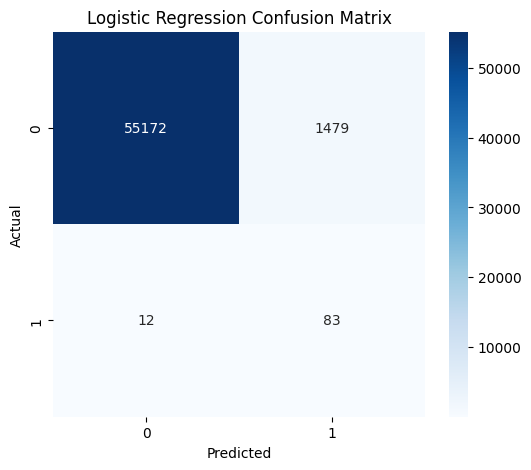

In [93]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

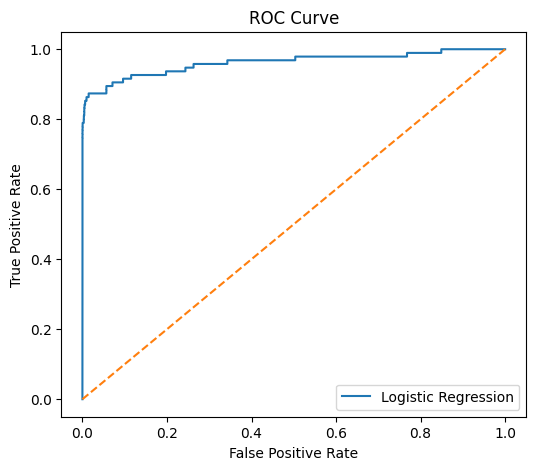

In [94]:
fpr, tpr, threshold = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [95]:
# ==========================================
# Create Representative Stratified Subset
# ==========================================

from sklearn.model_selection import train_test_split

X_tune, _, y_tune, _ = train_test_split(
    X_train_smote,
    y_train_smote,
    train_size=50000,
    stratify=y_train_smote,
    random_state=42
)

print("Subset Shape:", X_tune.shape)

print("\nClass Distribution:")
print(y_tune.value_counts())

Subset Shape: (50000, 30)

Class Distribution:
Class
0    25000
1    25000
Name: count, dtype: int64


In [96]:
# ==========================================
# Hyperparameter Tuning (Improved)
# ==========================================

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    verbose=2
)

grid.fit(X_tune, y_tune)

print("\nBest Parameters:")
print(grid.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   4.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   4.5s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   9.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   7.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  10.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   5.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   7.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   4.9s
[CV] END max_depth=10, min_sam

In [97]:
# ==========================================
# Train Final Optimized Model
# ==========================================

best_rf = RandomForestClassifier(
    n_estimators=grid.best_params_['n_estimators'],
    max_depth=grid.best_params_['max_depth'],
    min_samples_split=grid.best_params_['min_samples_split'],
    min_samples_leaf=grid.best_params_['min_samples_leaf'],
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_smote, y_train_smote)

print("Final Model Trained Successfully!")

Final Model Trained Successfully!


In [114]:
# ==========================================
# Predictions
# ==========================================

y_pred_best = best_rf.predict(X_test)

y_prob_best = best_rf.predict_proba(X_test)[:, 1]

In [115]:
# ==========================================
# Threshold Tuning
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [0.3, 0.4, 0.5, 0.6]:

    y_pred_threshold = (y_prob_best >= threshold).astype(int)

    print(f"\nThreshold = {threshold}")

    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall   :", recall_score(y_test, y_pred_threshold))
    print("F1 Score :", f1_score(y_test, y_pred_threshold))


Threshold = 0.3
Precision: 0.6902654867256637
Recall   : 0.8210526315789474
F1 Score : 0.75

Threshold = 0.4
Precision: 0.7755102040816326
Recall   : 0.8
F1 Score : 0.7875647668393783

Threshold = 0.5
Precision: 0.8314606741573034
Recall   : 0.7789473684210526
F1 Score : 0.8043478260869565

Threshold = 0.6
Precision: 0.9090909090909091
Recall   : 0.7368421052631579
F1 Score : 0.813953488372093


In [119]:
# ==========================================
# Final Predictions using Best Threshold
# ==========================================

best_threshold = 0.6

y_pred_final = (y_prob_best >= best_threshold).astype(int)

In [120]:
# ==========================================
# Final Model Evaluation
# ==========================================

print("="*60)
print("Final Random Forest Results (Threshold = 0.6)")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best))

Final Random Forest Results (Threshold = 0.6)
Accuracy : 0.9994360836006062
Precision: 0.9090909090909091
Recall   : 0.7368421052631579
F1 Score : 0.813953488372093
ROC AUC  : 0.9684131557114708


In [122]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.74      0.81        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



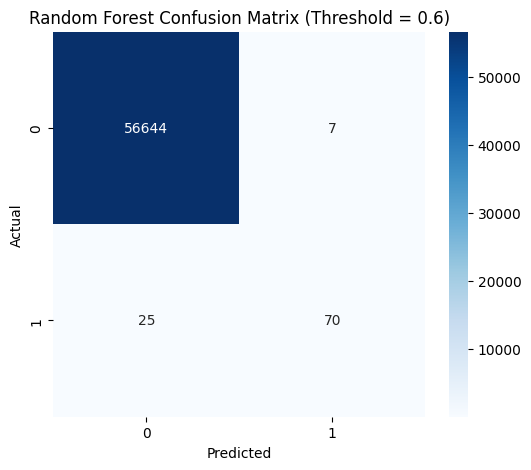

In [123]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix (Threshold = 0.6)")

plt.show()

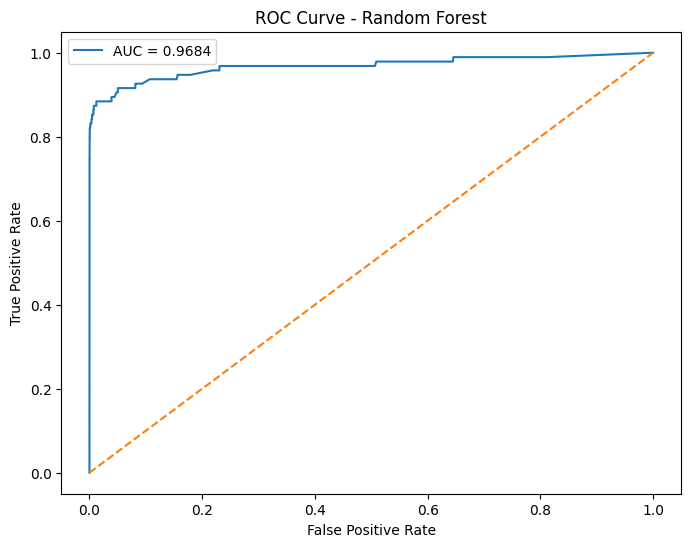

In [124]:
# ==========================================
# ROC Curve
# ==========================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_best):.4f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()